# Analysis of Ramps with WINTER Sensor


In [1]:
import os
import pandas as pd
import numpy as np
from analysis.cameras.winter.pipelines import WinterDataManager
from analysis.utils.image_database import (
    get_dark_frames_for_exposure, 
    get_light_frames_for_exposure, 
    get_unique_exposures_in_ascending_order
)

import matplotlib.pyplot as plt

In [2]:

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

data_dir = os.path.join(os.getenv("HOME"), "data", "winter", "qe_measurements", 
                        "qe_lab_20251209", 
                        "1050nm_SWIR_filter_ramp",
                        "exptimes_50_pts_per_exptime_10_20251209_122352",
)
"""
data_dir = os.path.join(os.getenv("HOME"), "data", "winter", "qe_measurements", 
                        "qe_lab_20251208", 
                        "1050nm_SWIR_filter_ramp",
                        "test_ramp_25pts",
)"""
print(f"Data directory: {data_dir}")
data_manager = WinterDataManager(data_dir=data_dir)
files = data_manager._get_files_in_directory(data_dir)
print(f"found {len(files)} files in data directory")

df = data_manager.crawl_fits_files()

# display the full dataframe
#display(df)

# get the unique exposure times
unique_exptimes = get_unique_exposures_in_ascending_order(df)
print("Unique exposure times (s):", unique_exptimes)



Data directory: /Users/nlourie/data/winter/qe_measurements/qe_lab_20251209/1050nm_SWIR_filter_ramp/exptimes_50_pts_per_exptime_10_20251209_122352
found 1000 files in data directory
Unique exposure times (s): [0.14, 0.162, 0.183, 0.205, 0.227, 0.248, 0.27, 0.291, 0.313, 0.335, 0.356, 0.378, 0.4, 0.421, 0.443, 0.464, 0.486, 0.508, 0.529, 0.551, 0.573, 0.594, 0.616, 0.638, 0.659, 0.681, 0.702, 0.724, 0.746, 0.767, 0.789, 0.811, 0.832, 0.854, 0.876, 0.897, 0.919, 0.94, 0.962, 0.984, 1.005, 1.027, 1.049, 1.07, 1.092, 1.113, 1.135, 1.157, 1.178, 1.2]


In [3]:
# mask out the bad channels in this dataset
def make_bad_mask(shape, active='even', col_phase=2, invert=False):
    h, w = shape
    col = (np.arange(w) - (col_phase % 4)) % 4
    bad_cols = (col < 2) if invert else (col >= 2)  # default: 2 good (0,1), 2 bad (2,3)
    if active == 'even':
        row_sel = (np.arange(h) % 2 == 0)
    elif active == 'odd':
        row_sel = (np.arange(h) % 2 == 1)
    elif active == 'all':
        row_sel = np.ones(h, dtype=bool)
    else:
        raise ValueError("active must be 'even', 'odd', or 'all'")
    mask = np.zeros((h, w), dtype=bool)
    mask[row_sel, :] = bad_cols
    return mask

light_data shape: (10, 1096, 1984), dtype: float32


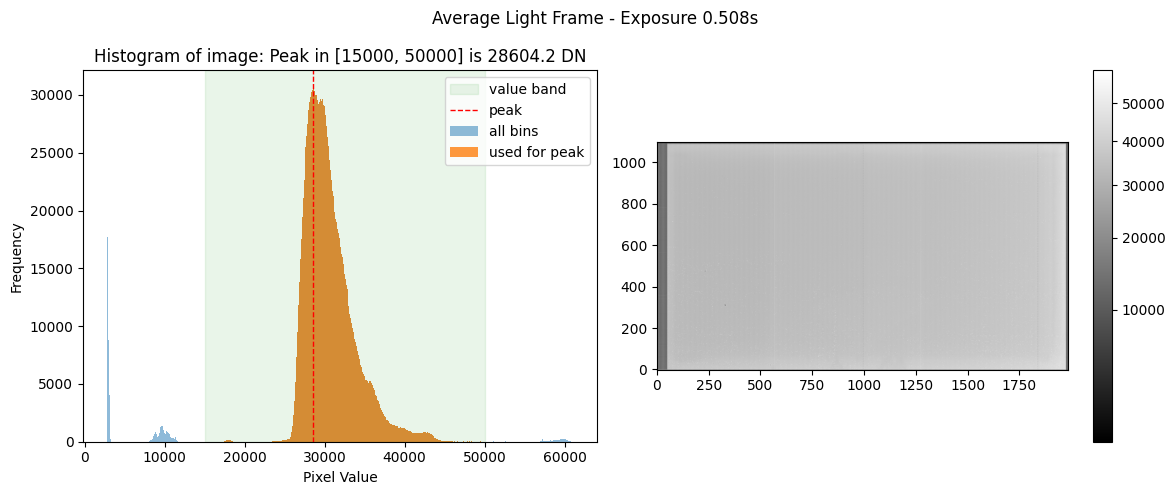

{'peak_value': 28604.1796875,
 'fig': <Figure size 1200x500 with 3 Axes>,
 'axes': array([<Axes: title={'center': 'Histogram of image: Peak in [15000, 50000] is 28604.2 DN'}, xlabel='Pixel Value', ylabel='Frequency'>,
        <Axes: >], dtype=object)}

In [4]:
# sample frames
from analysis.utils.utils import plot_image_with_histogram

exptime = 0.508
light_df = get_light_frames_for_exposure(df, exposure=exptime)
dark_df = get_dark_frames_for_exposure(df, exposure=exptime)

# turn all the light data into a 3D numpy array
light_data = np.stack(light_df['data'].to_list())

print(f"light_data shape: {light_data.shape}, dtype: {light_data.dtype}")

avg_light = np.mean(light_data, axis=0)

plot_image_with_histogram(
    avg_light, 
    title=f"Average Light Frame - Exposure {exptime}s",
    bad_mask = make_bad_mask(shape=avg_light.shape),
    band_min = 15000,
    band_max = 50000,
    bins = 500,
)


In [5]:
# analyze and channelize the frames

channelized_dirs = data_manager.process_and_channelize_data(data_dir)


Found 1000 FITS files to process
Creating master mask from bench_20251209_texp_0.14_light_lockin_0.062950V_freq_200Hz_gain_100000000.0_-8.49C_1050nm_20251209-172508-533.fits
Saved mask for channel 1 to /Users/nlourie/data/winter/qe_measurements/qe_lab_20251209/1050nm_SWIR_filter_ramp/exptimes_50_pts_per_exptime_10_20251209_122352/ch_1/master_mask_ch_1.fits
Saved mask for channel 2 to /Users/nlourie/data/winter/qe_measurements/qe_lab_20251209/1050nm_SWIR_filter_ramp/exptimes_50_pts_per_exptime_10_20251209_122352/ch_2/master_mask_ch_2.fits
Saved mask for channel 3 to /Users/nlourie/data/winter/qe_measurements/qe_lab_20251209/1050nm_SWIR_filter_ramp/exptimes_50_pts_per_exptime_10_20251209_122352/ch_3/master_mask_ch_3.fits
Saved mask for channel 4 to /Users/nlourie/data/winter/qe_measurements/qe_lab_20251209/1050nm_SWIR_filter_ramp/exptimes_50_pts_per_exptime_10_20251209_122352/ch_4/master_mask_ch_4.fits
Saved mask for channel 5 to /Users/nlourie/data/winter/qe_measurements/qe_lab_20251209

Processing channel 1
light_data shape: (548, 496), dtype: >f4


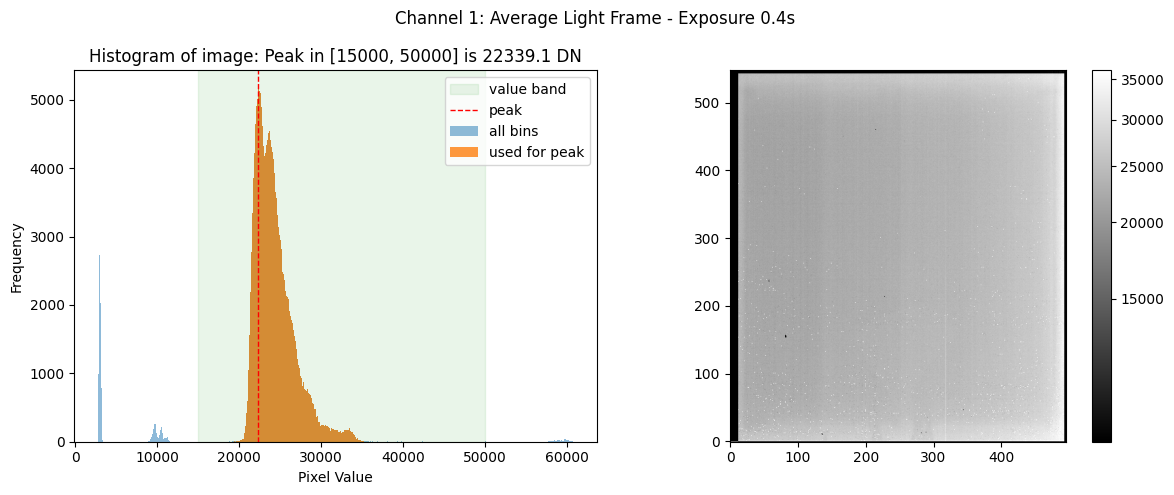

Processing channel 2
light_data shape: (548, 496), dtype: >f4


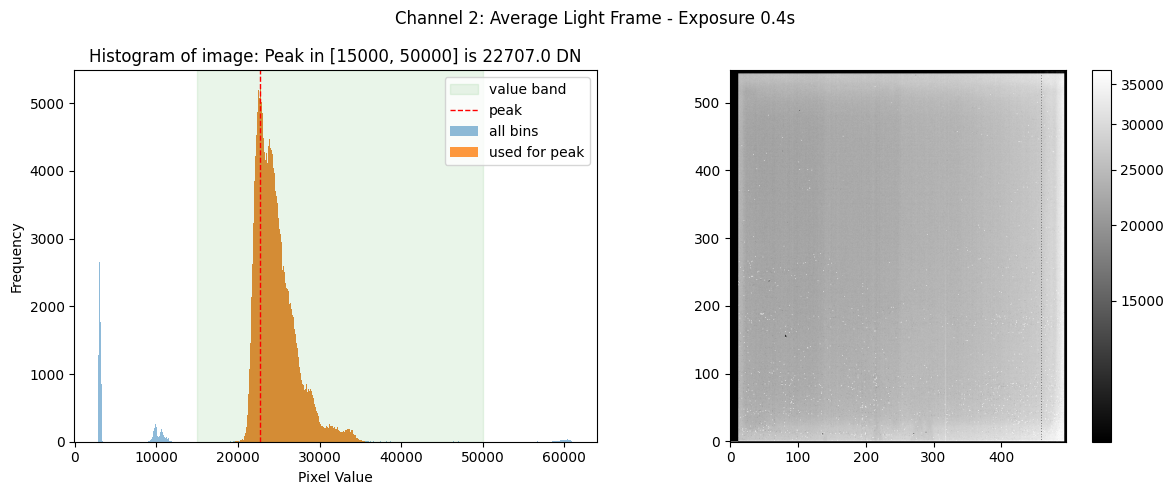

Processing channel 3
light_data shape: (548, 496), dtype: >f4


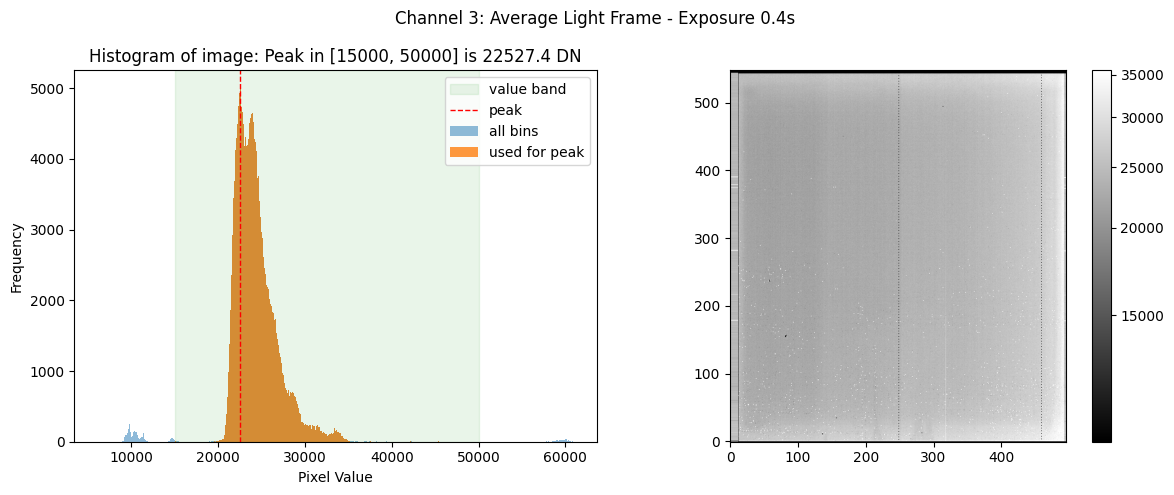

Processing channel 4
light_data shape: (548, 496), dtype: >f4


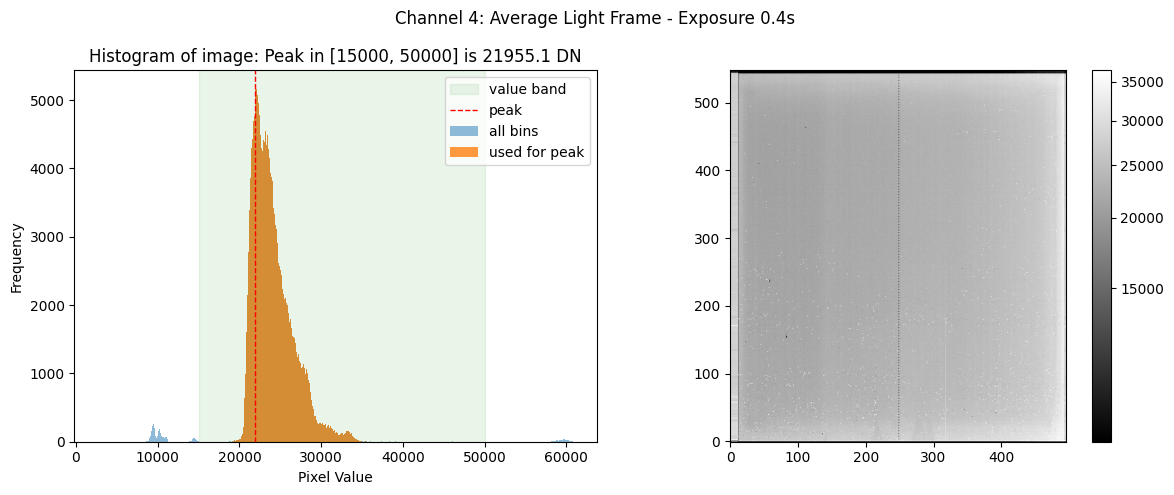

Processing channel 5
light_data shape: (548, 496), dtype: >f4


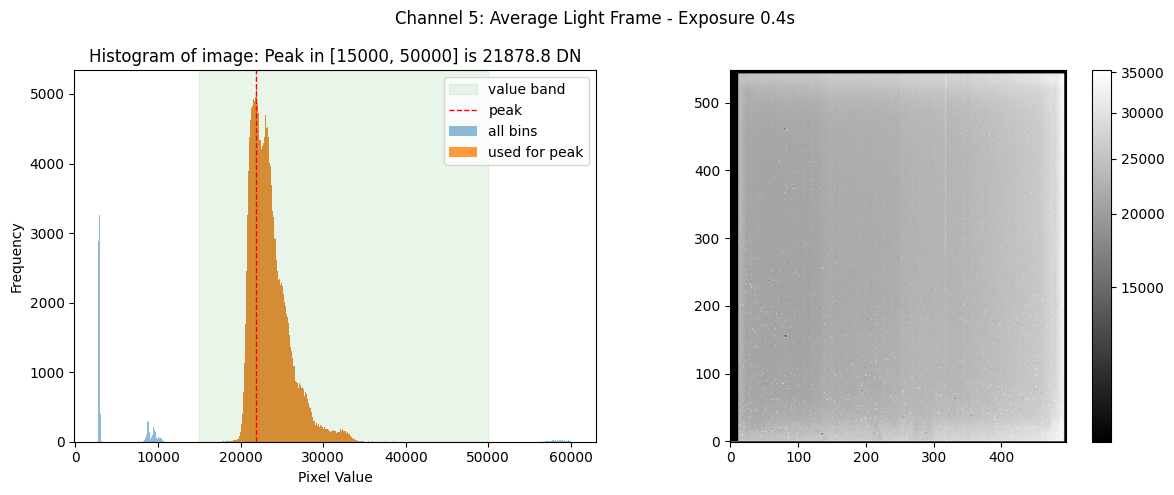

Processing channel 6
light_data shape: (548, 496), dtype: >f4


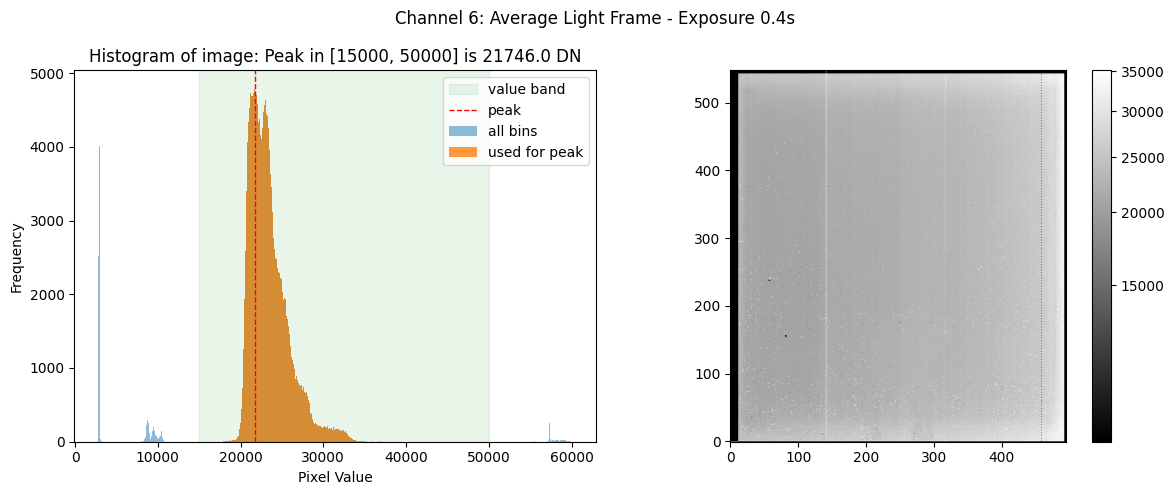

Processing channel 7
light_data shape: (548, 496), dtype: >f4


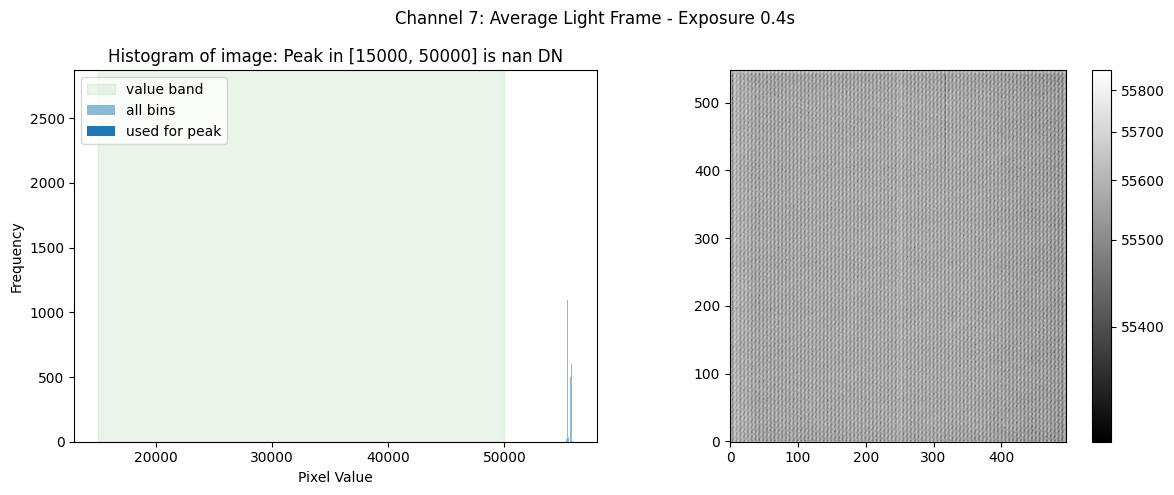

Processing channel 8
light_data shape: (548, 496), dtype: >f4


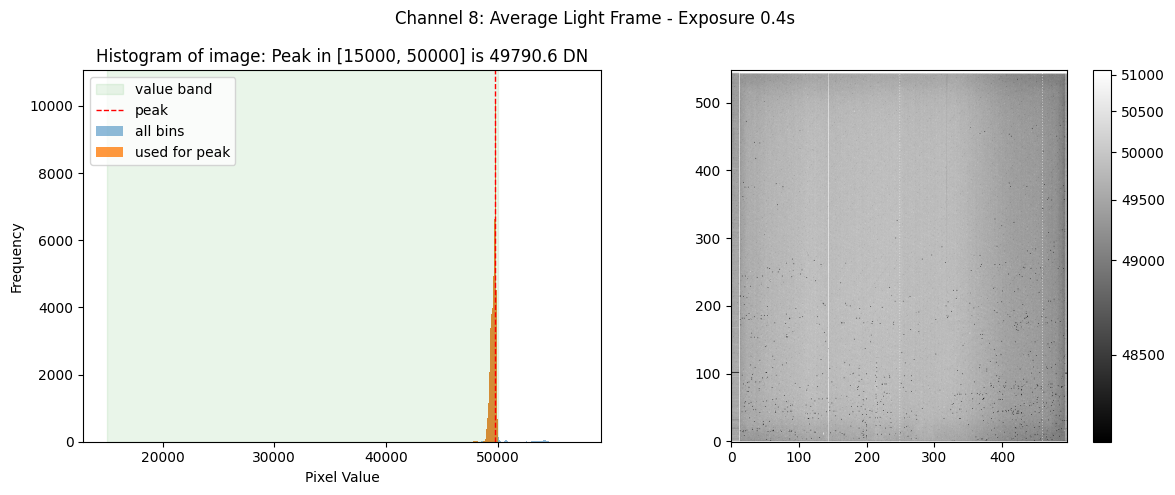

In [11]:
channel_number = 1

for channel_number in np.arange(1,9,1):
    print(f"Processing channel {channel_number}")
    ch_dir = channelized_dirs[channel_number]


    data_manager = WinterDataManager(data_dir=ch_dir)

    df = data_manager.crawl_fits_files()

    exptime = 0.4
    light_df = get_light_frames_for_exposure(df, exposure=exptime)
    dark_df = get_dark_frames_for_exposure(df, exposure=exptime)
    #display(light_df)
    # turn all the light data into a 3D numpy array
    light_data = light_df.iloc[0]['data']
    #plt.imshow(light_data, cmap='gray', vmin=0, vmax=60000)


    print(f"light_data shape: {light_data.shape}, dtype: {light_data.dtype}")


    plot_image_with_histogram(
        light_data, 
        title=f"Channel {channel_number}: Average Light Frame - Exposure {exptime}s",
        #bad_mask = datasec_mask,
        bad_mask = make_bad_mask(shape=light_data.shape, active='even', col_phase=2, invert=False),
        band_min = 15000,
        band_max = 50000,
        bins = 500,
    )


darksub_mean_frame_per_exptime shape: (50, 548, 496)
darksub_var_frame_per_exptime shape: (50, 548, 496)
Processing channel 1, exptime 0.14s
light_stack shape: (10, 548, 496)
dark_stack shape:  (10, 548, 496)
mask shape: (10, 548, 496)
corrected_light_stack shape: (10, 548, 496)
darksub_stack_mask shape: (10, 548, 496)
Processing channel 1, exptime 0.162s
light_stack shape: (10, 548, 496)
dark_stack shape:  (10, 548, 496)
mask shape: (10, 548, 496)
Flagging frame 6 as bad (deviation: 26.0)
corrected_light_stack shape: (10, 548, 496)
darksub_stack_mask shape: (10, 548, 496)
Processing channel 1, exptime 0.183s
light_stack shape: (10, 548, 496)
dark_stack shape:  (10, 548, 496)
mask shape: (10, 548, 496)
corrected_light_stack shape: (10, 548, 496)
darksub_stack_mask shape: (10, 548, 496)
Processing channel 1, exptime 0.205s
light_stack shape: (10, 548, 496)
dark_stack shape:  (10, 548, 496)
mask shape: (10, 548, 496)
corrected_light_stack shape: (10, 548, 496)
darksub_stack_mask shape: (

/var/folders/v4/c0sck65j1l3cwj3lsnz2fs380000gn/T/ipykernel_30821/1068852106.py:129: RuntimeWarning: Mean of empty slice
  avg_darksub_frame = np.nanmean(darksub_nan_masked_stack, axis=0)
/var/folders/v4/c0sck65j1l3cwj3lsnz2fs380000gn/T/ipykernel_30821/1068852106.py:130: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_darksub_frame = np.nanvar(darksub_nan_masked_stack, axis=0)
/var/folders/v4/c0sck65j1l3cwj3lsnz2fs380000gn/T/ipykernel_30821/1068852106.py:135: RuntimeWarning: Mean of empty slice
  frame_avg_ptc_means_per_exptime[i] = np.nanmean(avg_darksub_frame)
/var/folders/v4/c0sck65j1l3cwj3lsnz2fs380000gn/T/ipykernel_30821/1068852106.py:136: RuntimeWarning: Mean of empty slice
  frame_avg_ptc_vars_per_exptime[i] = np.nanmean(var_darksub_frame)


Flagging frame 4 as bad (deviation: 117.5)
corrected_light_stack shape: (10, 548, 496)
darksub_stack_mask shape: (10, 548, 496)
Processing channel 1, exptime 0.356s
light_stack shape: (10, 548, 496)
dark_stack shape:  (10, 548, 496)
mask shape: (10, 548, 496)
Flagging frame 5 as bad (deviation: 126.0)
corrected_light_stack shape: (10, 548, 496)
darksub_stack_mask shape: (10, 548, 496)
Processing channel 1, exptime 0.378s
light_stack shape: (10, 548, 496)
dark_stack shape:  (10, 548, 496)
mask shape: (10, 548, 496)
Flagging frame 1 as bad (deviation: 85.5)
Flagging frame 9 as bad (deviation: 20.5)
corrected_light_stack shape: (10, 548, 496)
darksub_stack_mask shape: (10, 548, 496)
Processing channel 1, exptime 0.4s
light_stack shape: (10, 548, 496)
dark_stack shape:  (10, 548, 496)
mask shape: (10, 548, 496)
corrected_light_stack shape: (10, 548, 496)
darksub_stack_mask shape: (10, 548, 496)
Processing channel 1, exptime 0.421s
light_stack shape: (10, 548, 496)
dark_stack shape:  (10, 5

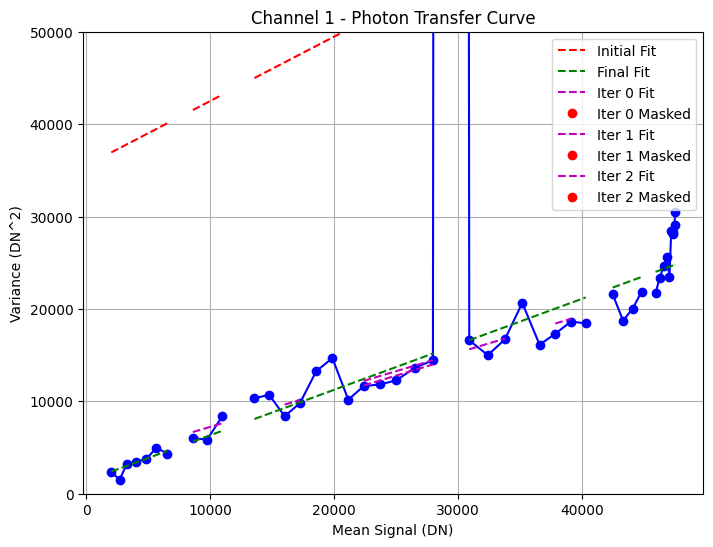

In [109]:
# Quick PTC

channel_number = 1

ch_dir = channelized_dirs[channel_number]
data_manager = WinterDataManager(data_dir=ch_dir)

df = data_manager.crawl_fits_files()

def mask_outlier_layers(stack, mask = None, n_sigma=2, plot = False, title = ""):
    """
    Given a 3D stack of images (num_frames, height, width),
    identify and mask outlier frames based on their deviation
    from the median frame.
    Returns a boolean mask of shape (num_frames, height, width)
    where True indicates a bad pixel/frame.
    """
    if mask is None:
        mask = np.zeros_like(stack, dtype=bool)

    stack_median_frame = np.median(stack, axis=0)

    diff_stack = np.abs(stack - stack_median_frame[None, :, :])

    # get the median of the difference over each frame in the diff_stack
    diff_median_per_frame = np.median(diff_stack, axis=(1,2))

    global_median = np.median(diff_median_per_frame)
    std_median = np.std(diff_median_per_frame)
    cutoff_threshold = n_sigma*std_median

    # update the mask to flag bad frames
    for i, val in enumerate(diff_median_per_frame):
        if np.abs(val - global_median) > cutoff_threshold:
            print(f"Flagging frame {i} as bad (deviation: {val})")
            mask[i, :, :] = True  # flag entire frame as bad

    if plot:
        plt.figure()
        plt.plot(diff_median_per_frame, 'ro')
        # plot the diff_median_per_frame that are not masked
        plt.plot(
            np.where(~mask.any(axis=(1,2)), diff_median_per_frame, np.nan), 
            'bo', label='Good Frames'
        )
        plt.xlabel("Frame Index")
        plt.ylabel("Median Absolute Deviation from Median Frame")
        plt.title(title)
        plt.axhline(global_median, color='k', linestyle='--', label='Global Median')
        plt.axhline(global_median + cutoff_threshold, color='r', linestyle='--', label=f'{n_sigma}-Sigma Threshold')
        plt.axhline(global_median - cutoff_threshold, color='r', linestyle='--', label=f'{n_sigma}-Sigma Threshold')

    return mask

#init the ptc mean and var arrays as nan np arrays
exptimes = np.array(get_unique_exposures_in_ascending_order(df))
# mean/var averaged over the full frame
frame_avg_ptc_means_per_exptime = np.full(len(exptimes), np.nan)
frame_avg_ptc_vars_per_exptime = np.full(len(exptimes), np.nan)
frame_avg_mask_per_exptime = np.zeros_like(len(exptimes), dtype=bool)
frame_shape = df.iloc[0]['data'].shape

# mean/var frames (height, width) per exptime
darksub_mean_frame_per_exptime = np.full((len(exptimes),) + frame_shape, np.nan)
darksub_var_frame_per_exptime = np.full((len(exptimes),) + frame_shape, np.nan)
print(f"darksub_mean_frame_per_exptime shape: {darksub_mean_frame_per_exptime.shape}")
print(f"darksub_var_frame_per_exptime shape: {darksub_var_frame_per_exptime.shape}")

for i, exptime in enumerate(exptimes):
    print(f"Processing channel {channel_number}, exptime {exptime}s")
    light_df = get_light_frames_for_exposure(df, exposure=exptime)
    dark_df = get_dark_frames_for_exposure(df, exposure=exptime)

    light_stack = np.stack(light_df['data'].to_list())
    dark_stack = np.stack(dark_df['data'].to_list())
    print(f"light_stack shape: {light_stack.shape}")
    print(f"dark_stack shape:  {dark_stack.shape}")

    # first step: make a mask of bad pixels
    light_mask = np.zeros_like(light_stack, dtype=bool)
    dark_mask = np.zeros_like(dark_stack, dtype=bool)
    print(f"mask shape: {light_mask.shape}")

    # the stacks are (num_frames, height, width)
    # 1. throw out bad frames
    plot = False
    n_sigma = 2.5
    light_mask = mask_outlier_layers(light_stack, mask=light_mask, n_sigma=n_sigma, plot=plot, 
        title=f"Ch {channel_number}: LIGHT - Masking Outlier Frames: Exptime {exptime}s"
                               )
    dark_mask = mask_outlier_layers(dark_stack, mask=dark_mask, n_sigma=n_sigma, plot=plot, 
        title=f"Ch {channel_number}: DARK - Masking Outlier Frames: Exptime {exptime}s"
                               )

    # 2. make a mean dark frame and flatten its mask to 2d
    mean_dark = np.nanmean(dark_stack, axis=0)
    mean_dark_mask = np.any(dark_mask, axis=0)  # 2D mask of bad pixels in mean dark

    # plot the masked mean dark
    plot_mean_dark = False
    if plot_mean_dark:
        plot_image_with_histogram(
            mean_dark, 
            title=f"Channel {channel_number}: Mean Dark Frame - Exptime {exptime}s",
            bad_mask = mean_dark_mask,
            band_min = 1000,
            band_max = 20000,
            bins = 500,
        )

    # 3. subtract the mean dark from each frame in the light stack, and combine the masks
    corrected_light_stack = light_stack - mean_dark[None, :, :]
    darksub_stack_mask = light_mask | mean_dark_mask[None, :, :]
    print(f"corrected_light_stack shape: {corrected_light_stack.shape}")    
    print(f"darksub_stack_mask shape: {darksub_stack_mask.shape}")
    plot_mean_darksub = False
    if plot_mean_darksub:
        plot_image_with_histogram(
            np.mean(corrected_light_stack, axis=0), 
            title=f"Channel {channel_number}: Mean Dark-Subtracted Light Frame - Exptime {exptime}s",
            bad_mask = np.any(darksub_stack_mask, axis=0),
            band_min = 100,
            band_max = 60000,
            bins = 500,
        )

    # 4. compute the average light frame and stddev frame, ignoring masked pixels
    darksub_nan_masked_stack = np.where(darksub_stack_mask, np.nan, corrected_light_stack)
    avg_darksub_frame = np.nanmean(darksub_nan_masked_stack, axis=0)
    var_darksub_frame = np.nanvar(darksub_nan_masked_stack, axis=0)
    
    darksub_mean_frame_per_exptime[i] = avg_darksub_frame
    darksub_var_frame_per_exptime[i] = var_darksub_frame
    # 5. compute the mean and variance over all unmasked pixels
    frame_avg_ptc_means_per_exptime[i] = np.nanmean(avg_darksub_frame)
    frame_avg_ptc_vars_per_exptime[i] = np.nanmean(var_darksub_frame)

# plot the mean PTC
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(frame_avg_ptc_means_per_exptime, frame_avg_ptc_vars_per_exptime, 'bo-')
ax.set_xlabel("Mean Signal (DN)")
ax.set_ylabel("Variance (DN^2)")
ax.set_title(f"Channel {channel_number} - Photon Transfer Curve")
ax.set_ylim(0., 50000)
plt.grid()

# do outlier rejection of exposure times based on mean PTC curve
print(f"there are {len(frame_avg_ptc_means_per_exptime)} points in the PTC curve")
print(f"shape of darksub_mean_frame_per_exptime: {darksub_mean_frame_per_exptime.shape}")

# fit a line to the PTC curve and reject outliers: only the points that are not nan
fit = np.polyfit(frame_avg_ptc_means_per_exptime[~np.isnan(frame_avg_ptc_means_per_exptime)], 
                 frame_avg_ptc_vars_per_exptime[~np.isnan(frame_avg_ptc_vars_per_exptime)], 1)
print(f"Initial fit coefficients: {fit}")

ax.plot(frame_avg_ptc_means_per_exptime, 
        np.polyval(fit, frame_avg_ptc_means_per_exptime), 'r--', label='Initial Fit')
#plt.legend()

diffs = frame_avg_ptc_vars_per_exptime - np.polyval(fit, frame_avg_ptc_means_per_exptime)
std_diffs = np.std(diffs[~np.isnan(diffs)])
mean_diffs = np.mean(diffs[~np.isnan(diffs)])
n_sigma = 2.0
frame_avg_mask_per_exptime = np.abs(diffs - mean_diffs) > n_sigma*std_diffs

# change any points in the arrays that are masked to nan
frame_avg_ptc_means_per_exptime[frame_avg_mask_per_exptime] = np.nan
frame_avg_ptc_vars_per_exptime[frame_avg_mask_per_exptime] = np.nan

print(f"masked out these exposure times: {exptimes[frame_avg_mask_per_exptime]}s")
# plot the final fit after masking outliers
fit_final = np.polyfit(frame_avg_ptc_means_per_exptime[~np.isnan(frame_avg_ptc_means_per_exptime)], 
                 frame_avg_ptc_vars_per_exptime[~np.isnan(frame_avg_ptc_vars_per_exptime)], 1)
print(f"Final fit coefficients: {fit_final}")   
ax.plot(frame_avg_ptc_means_per_exptime, 
        np.polyval(fit_final, frame_avg_ptc_means_per_exptime), 'g--', label='Final Fit')

# further masking:
# mask exposure times where mean is outside a given range
min_mean_signal = 5000
max_mean_signal = 40000
additional_mask = (frame_avg_ptc_means_per_exptime < min_mean_signal) | (frame_avg_ptc_means_per_exptime > max_mean_signal)
frame_avg_ptc_means_per_exptime[additional_mask] = np.nan
frame_avg_ptc_vars_per_exptime[additional_mask] = np.nan
print(f"additionally masked out these exposure times: {exptimes[additional_mask]}s")    

# do another iterative sigma clipping based on residuals
for iteration in range(3):
    fit_iter = np.polyfit(frame_avg_ptc_means_per_exptime[~np.isnan(frame_avg_ptc_means_per_exptime)], 
                     frame_avg_ptc_vars_per_exptime[~np.isnan(frame_avg_ptc_vars_per_exptime)], 1)
    diffs_iter = frame_avg_ptc_vars_per_exptime - np.polyval(fit_iter, frame_avg_ptc_means_per_exptime)
    std_diffs_iter = np.std(diffs_iter[~np.isnan(diffs_iter)])
    mean_diffs_iter = np.mean(diffs_iter[~np.isnan(diffs_iter)])
    n_sigma = 1.0
    iter_mask = np.abs(diffs_iter - mean_diffs_iter) > n_sigma*std_diffs_iter
    frame_avg_ptc_means_per_exptime[iter_mask] = np.nan
    frame_avg_ptc_vars_per_exptime[iter_mask] = np.nan
    print(f"Iteration {iteration}: masked out these exposure times: {exptimes[iter_mask]}s")
    plt.plot(frame_avg_ptc_means_per_exptime, 
        np.polyval(fit_iter, frame_avg_ptc_means_per_exptime), 'm--', label=f'Iter {iteration} Fit')   
    # plot the masked points
    plt.plot(frame_avg_ptc_means_per_exptime[iter_mask], frame_avg_ptc_vars_per_exptime[iter_mask], 'ro', label=f'Iter {iteration} Masked')
plt.legend()